In [ ]:
# using GNNs to build network graph from nmap output

# Read the XML `nmap` Output
- Parse `.xml` into nodes, edges, attributes.

Note:
What I have now is not universal, I will need our true `nmap` scans to make this one-size fits all.

In [1]:
import xml.etree.ElementTree as ET  # ElementTree library is used to parse XML data
import os

xml1 = "../data/nmap_output.xml"
xml2 = "../data/nmap_output_adv.xml"
xml3 = "../data/nmap_stress_test.xml"
xml4 = "../data/2025-10-21T09_58_54_830050Z_nmap.xml"



In [2]:
def xml_parse(xml_data):
    """
    Parses nmap XML output into structured dictionary form.
    Handles missing fields gracefully.
    """
    network_config = {}
    
    # nothing in the xml file
    if not xml_data:
        return {}
    
    # get the xml_ouput (either string or XML file)
    try:
        if os.path.exists(xml_data):
            tree = ET.parse(xml_data)
            root = tree.getroot()
        else:
            s = xml_data.strip()

            if not (s.startswith("<")):  # check if the string is XML looking
                return {"error": "~INPUT DOES NOT APPEAR TO BE XML"}
            
            root = ET.fromstring(s)

    except ET.ParseError as pe:
        return {"error": f"~ISSUE PARSING ELEMENTTREE: {pe}"}
    except Exception as e:
        return {"error": f"~UNEXPECTED ERROR PARSING XML: {e}"}

    for host in root.findall("host"):
        host_addr = None
        host_name = None
        port_lst = []  # ✅ Always initialize this

        # --- Extract address ---
        addr_elem = host.find("address")
        if addr_elem is not None:
            host_addr = addr_elem.attrib.get("addr")

        # --- Extract hostname (optional) ---
        hostnames_elem = host.find("hostnames/hostname")
        if hostnames_elem is not None:
            host_name = hostnames_elem.attrib.get("name")

        # --- Extract ports (if any) ---
        ports_elem = host.find("ports")
        if ports_elem is not None:
            for port in ports_elem.findall("port"):
                port_id = port.attrib.get("portid")
                protocol = port.attrib.get("protocol")
                state_elem = port.find("state")
                service_elem = port.find("service")

                state = state_elem.attrib.get("state") if state_elem is not None else "unknown"
                service = service_elem.attrib.get("name") if service_elem is not None else "unknown"

                port_lst.append({
                    "port": port_id,
                    "protocol": protocol,
                    "state": state,
                    "service": service
                })

        # --- Store host summary ---
        if host_addr:
            network_config[host_addr] = {
                "hostname": host_name or "unknown",
                "ports": port_lst,  # ✅ Safe even if empty
            }

    return network_config


network = xml_parse(xml4)
print(network)

{'10.10.162.98': {'hostname': 'unknown', 'ports': [{'port': '5000', 'protocol': 'tcp', 'state': 'open', 'service': 'upnp'}, {'port': '5003', 'protocol': 'tcp', 'state': 'open', 'service': 'filemaker'}, {'port': '7000', 'protocol': 'tcp', 'state': 'open', 'service': 'afs3-fileserver'}, {'port': '49153', 'protocol': 'tcp', 'state': 'open', 'service': 'unknown'}]}, '10.10.162.163': {'hostname': 'unknown', 'ports': [{'port': '22', 'protocol': 'tcp', 'state': 'open', 'service': 'ssh'}, {'port': '80', 'protocol': 'tcp', 'state': 'open', 'service': 'http'}, {'port': '443', 'protocol': 'tcp', 'state': 'open', 'service': 'https'}]}, '10.10.162.177': {'hostname': 'unknown', 'ports': [{'port': '49152', 'protocol': 'tcp', 'state': 'open', 'service': 'unknown'}, {'port': '62078', 'protocol': 'tcp', 'state': 'open', 'service': 'iphone-sync'}]}, '10.10.162.236': {'hostname': 'unknown', 'ports': [{'port': '62078', 'protocol': 'tcp', 'state': 'open', 'service': 'iphone-sync'}]}}


In [ ]:
tree = ET.parse(xml1)
root = tree.getroot()  # tag that envelopes everything
root.attrib  # length of 6 (scaninfo, host1, host2, host3, host4, runstats)

In [16]:
# loop over root children and their sub attributes
# find each HOST element
network = {}
for child in root: 
    network_config = {}

    # skip over none host elements
    if child.tag != "host":
        continue

    # pull all IP hosts found (up/down)
    addr = child.findall("address")  # might not be universal (can have ipv4/mac)
    ip_addr = None
    mac_addr = None
    for a in addr:
        # store ipv4 as the main key
        if a.attrib["addrtype"] == "ipv4":
            ip_addr = a.attrib["addr"]

        # if a mac address exists store it
        if a.attrib["addrtype"] == "mac":
            # store other address types
            mac_addr = a.attrib["addr"]
            vendor = a.attrib.get("vendor", None)
            network_config["address"] = {"mac_addr" : mac_addr, "vendor": vendor}

    # use mac as main key if ipv4 not available
    if not ip_addr and mac_addr is not None:
        print("~NO IPV4 VALUE USING MAC INSTEAD")
        ip_addr = mac_addr
        
    # find host's state
    status = child.find("status").attrib["state"]
    if status != "up":  # host is down
        network_config["os"] = None
        network_config["state"] = None
        network_config["hostname"] = None
        network_config["ports"] = None
    else:   # host is up
        # find IP hostname (might contain multiple or none)
        hostname_root = child.find("hostnames")
        if hostname_root is not None:
            hostname_list = []
            for host in hostname_root:
                hostname_list.append(host.attrib) 
        else:
            hostname_list = None

        # find IP OS (either single or multiple)
        os_root = child.find("os")
        if os_root is not None:
            osmatch = os_root.findall("osmatch")
            os_lst = []
            for o in osmatch:
                os_pred = o.attrib
                os_lst.append(os_pred)
            network_config["os"] = os_lst
        else: 
            network_config["os"] = None

        network_config["state"] = status 
        network_config["hostname"] = hostname_list  # store list of hostnames if contains multiple

        # find IP open ports
        port_root = child.find("ports")
        if port_root is not None:
            port_lst = []
            for port in port_root.findall("port"):
                port_data = dict(port.attrib)
                for child in port:
                    if child.tag in ("state", "service"):
                        port_data.update(child.attrib)
                port_lst.append(port_data)

        network_config["ports"] = port_lst

    # add the host into the dictionary
    network[ip_addr] = network_config
    
print(network)


NameError: name 'root' is not defined

## Turn ElementTree Dictionary into `networkx` graph.

In [3]:
print(network)

{'10.10.162.98': {'hostname': 'unknown', 'ports': [{'port': '5000', 'protocol': 'tcp', 'state': 'open', 'service': 'upnp'}, {'port': '5003', 'protocol': 'tcp', 'state': 'open', 'service': 'filemaker'}, {'port': '7000', 'protocol': 'tcp', 'state': 'open', 'service': 'afs3-fileserver'}, {'port': '49153', 'protocol': 'tcp', 'state': 'open', 'service': 'unknown'}]}, '10.10.162.163': {'hostname': 'unknown', 'ports': [{'port': '22', 'protocol': 'tcp', 'state': 'open', 'service': 'ssh'}, {'port': '80', 'protocol': 'tcp', 'state': 'open', 'service': 'http'}, {'port': '443', 'protocol': 'tcp', 'state': 'open', 'service': 'https'}]}, '10.10.162.177': {'hostname': 'unknown', 'ports': [{'port': '49152', 'protocol': 'tcp', 'state': 'open', 'service': 'unknown'}, {'port': '62078', 'protocol': 'tcp', 'state': 'open', 'service': 'iphone-sync'}]}, '10.10.162.236': {'hostname': 'unknown', 'ports': [{'port': '62078', 'protocol': 'tcp', 'state': 'open', 'service': 'iphone-sync'}]}}


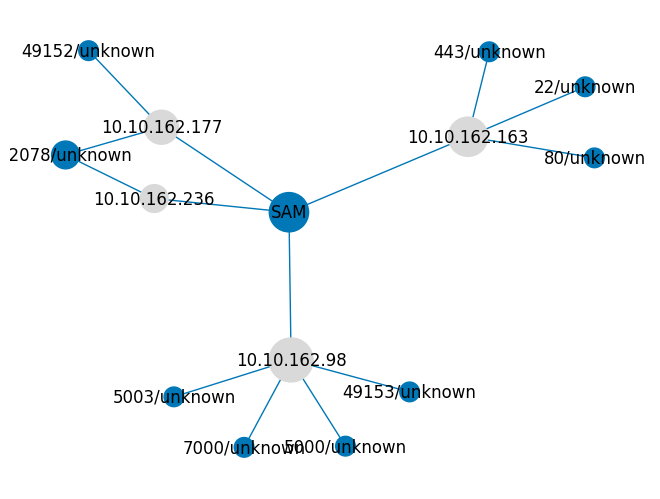

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
SCANNER = "SAM"
PORT_COLORS = {
    80: "#fb8500",  # web
    443: "#fb8500",  # web
    22: "#d9d9d9"  # ssh
}

# parse the dictionary to get the nodes (scanner -> IP -> Ports)
G.add_node(SCANNER)

for ip in network.keys():
    state = network[ip].get("state", "unknown")
    G.add_node(ip, color="#4c956c" if state == "up" else "#d9d9d9")  # adding a node to IP

    # if down connect using dashed lines
    if state != "up":
        G.add_edge(SCANNER, ip)
    else:
        G.add_edge(SCANNER, ip)

    # add port edges
    if network[ip]["ports"] is not None:
        for n in network[ip]["ports"]:
            # color code port edges
            # color = PORT_COLORS.get(int(n["portid"]), "#0077b6")
            service_label = f"{n['port']}/{n.get('name', 'unknown')}"

            G.add_node(service_label)
            G.add_edge(ip, service_label, color="#0077b6")


# display graph
# pull the colors used
node_colors = [G.nodes[n].get("color", "#0077b6") for n in G.nodes()]
edge_colors = nx.get_edge_attributes(G, "color").values()
node_degree = G.degree
nx.draw(
    G,
    # pos=nx.draw_spring(G),
    # pos=nx.multipartite_layout(G, subset_key=""), 
    node_color=node_colors,
    edge_color=edge_colors,
    with_labels= True,
    node_size=[v[1] * 200 for v in node_degree]
)

# plt.savefig("../output/nmap_RECENT_RUN.png")
plt.show()

## Turn `networkx` graph into GNN graph.

In [ ]:
import torch
from torch_geometric.utils.convert import to_networkx, from_networkx

pyg_graph = from_networkx(G)
pyg_graph

## Output GNN graph object.

## Next Steps
- `<extraports>` summarize/show closed ports
- define multiple  `<host>` with no IPv4 or MAC

These next steps can be tuned when we get actual nmap scans.